In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data Exploration

Assumptions:
Data are not manipulated


In [3]:
df=pd.read_csv("insurance_claims.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [4]:
df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [6]:
df.duplicated().sum() 

np.int64(0)

# Data Cleaning

In [25]:
# drop c_39
df.drop("_c39", axis =1, inplace=True)

### Time Series Exploration

In [ ]:
# change date in data object
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df['incident_date'])

In [23]:
print(df["incident_date"].min())
print(df["incident_date"].max())

2015-01-01
2015-03-01


In [16]:
print(df["policy_bind_date"].min())
print(df["policy_bind_date"].max())

1990-01-08
2015-02-22


In [37]:
df["fraud"]=df["fraud_reported"].apply(lambda x: 1 if str(x)=="Y" else 0)

In [26]:
col_quan = df.select_dtypes(include=['float64', 'int64']).columns
col_qual = df.drop(col_quan,axis=1).columns

In [32]:
def quant_var_stats(variable, df):
    display(np.round(df[variable].describe(),2))
    display(df[variable].nunique())
    sns.boxplot(x=variable, data=df)
    plt.show()


In [27]:
col_quan

Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
       'auto_year'],
      dtype='object')

count    1000.00
mean      203.95
std       115.11
min         0.00
25%       115.75
50%       199.50
75%       276.25
max       479.00
Name: months_as_customer, dtype: float64

391

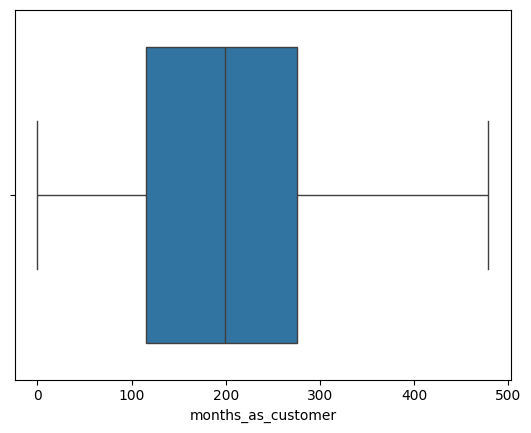

count    1000.00
mean       38.95
std         9.14
min        19.00
25%        32.00
50%        38.00
75%        44.00
max        64.00
Name: age, dtype: float64

46

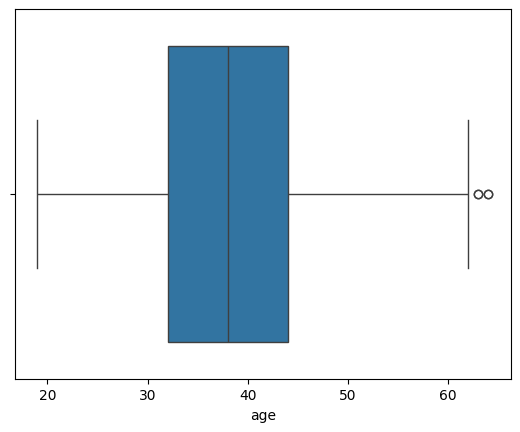

count      1000.00
mean     546238.65
std      257063.01
min      100804.00
25%      335980.25
50%      533135.00
75%      759099.75
max      999435.00
Name: policy_number, dtype: float64

1000

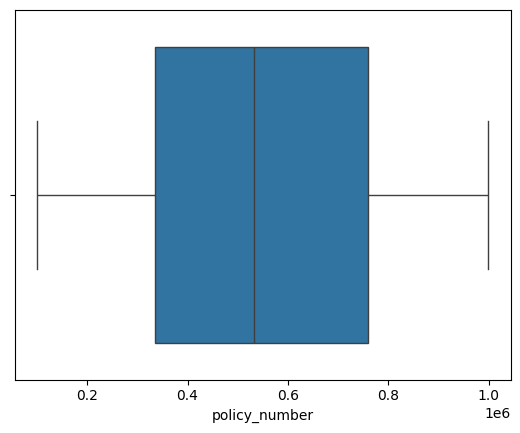

count    1000.00
mean     1136.00
std       611.86
min       500.00
25%       500.00
50%      1000.00
75%      2000.00
max      2000.00
Name: policy_deductable, dtype: float64

3

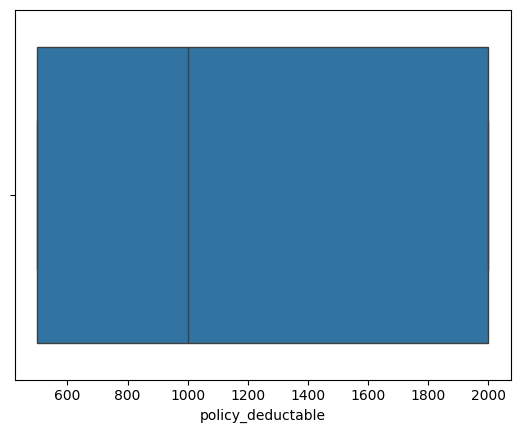

count    1000.00
mean     1256.41
std       244.17
min       433.33
25%      1089.61
50%      1257.20
75%      1415.70
max      2047.59
Name: policy_annual_premium, dtype: float64

991

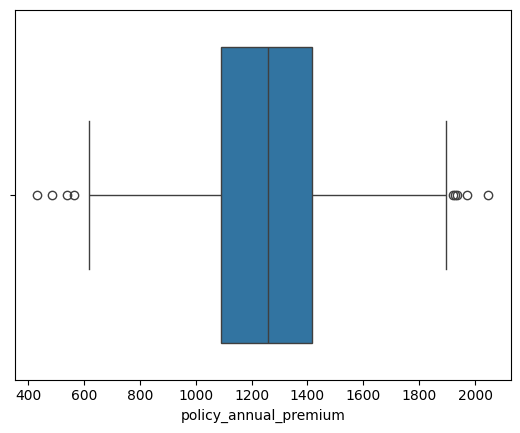

count        1000.0
mean      1101000.0
std       2297406.6
min      -1000000.0
25%             0.0
50%             0.0
75%             0.0
max      10000000.0
Name: umbrella_limit, dtype: float64

11

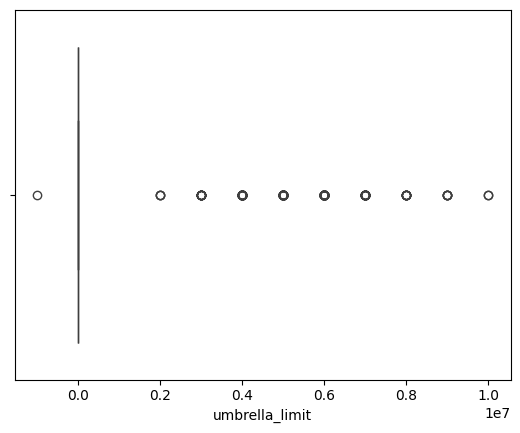

count      1000.00
mean     501214.49
std       71701.61
min      430104.00
25%      448404.50
50%      466445.50
75%      603251.00
max      620962.00
Name: insured_zip, dtype: float64

995

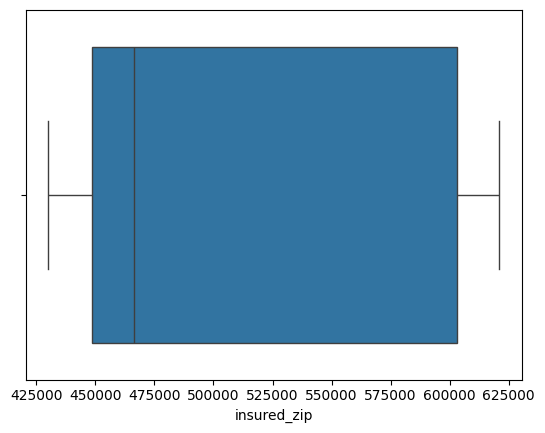

count      1000.00
mean      25126.10
std       27872.19
min           0.00
25%           0.00
50%           0.00
75%       51025.00
max      100500.00
Name: capital-gains, dtype: float64

338

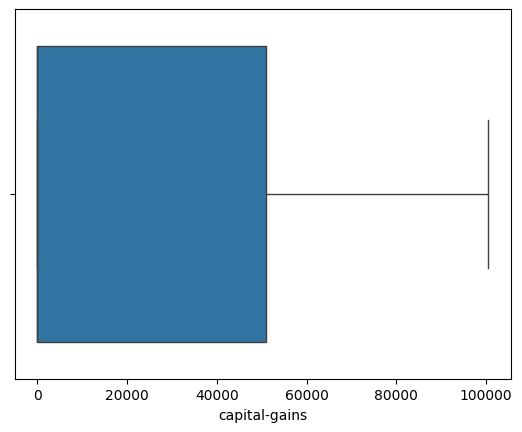

count      1000.0
mean     -26793.7
std       28104.1
min     -111100.0
25%      -51500.0
50%      -23250.0
75%           0.0
max           0.0
Name: capital-loss, dtype: float64

354

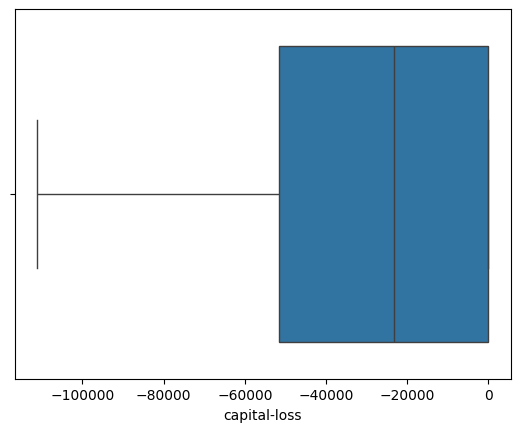

count    1000.00
mean       11.64
std         6.95
min         0.00
25%         6.00
50%        12.00
75%        17.00
max        23.00
Name: incident_hour_of_the_day, dtype: float64

24

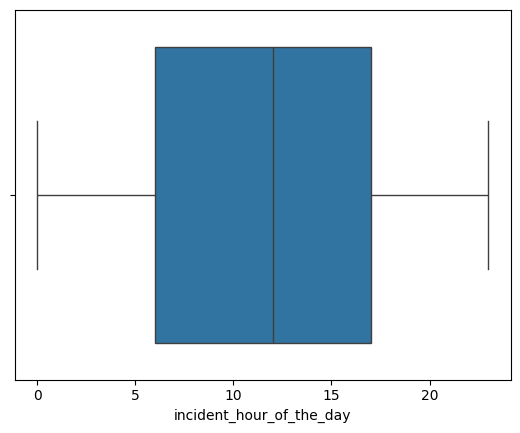

count    1000.00
mean        1.84
std         1.02
min         1.00
25%         1.00
50%         1.00
75%         3.00
max         4.00
Name: number_of_vehicles_involved, dtype: float64

4

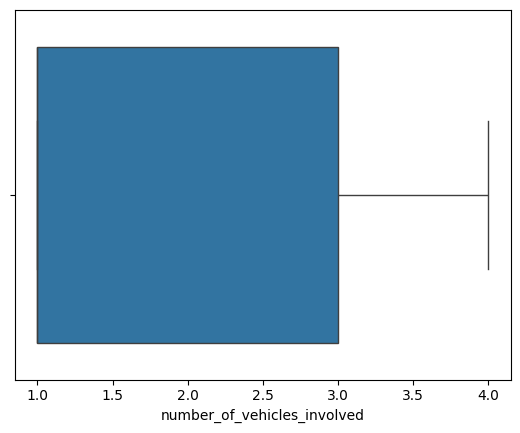

count    1000.00
mean        0.99
std         0.82
min         0.00
25%         0.00
50%         1.00
75%         2.00
max         2.00
Name: bodily_injuries, dtype: float64

3

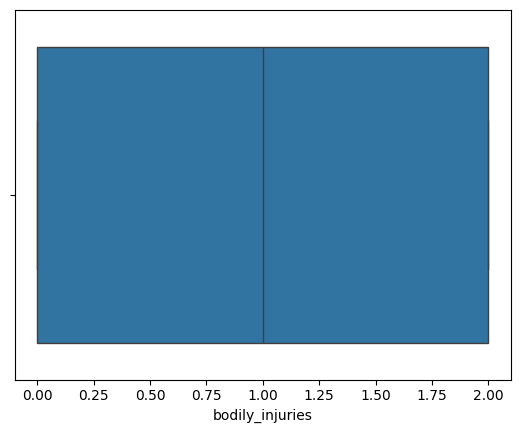

count    1000.00
mean        1.49
std         1.11
min         0.00
25%         1.00
50%         1.00
75%         2.00
max         3.00
Name: witnesses, dtype: float64

4

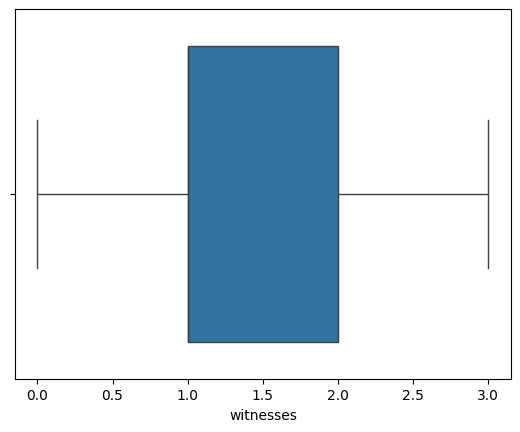

count      1000.00
mean      52761.94
std       26401.53
min         100.00
25%       41812.50
50%       58055.00
75%       70592.50
max      114920.00
Name: total_claim_amount, dtype: float64

763

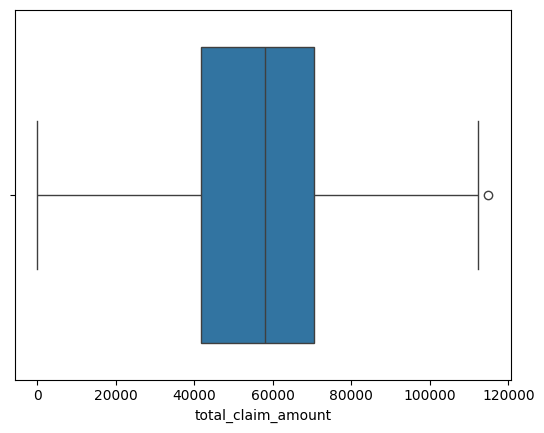

count     1000.00
mean      7433.42
std       4880.95
min          0.00
25%       4295.00
50%       6775.00
75%      11305.00
max      21450.00
Name: injury_claim, dtype: float64

638

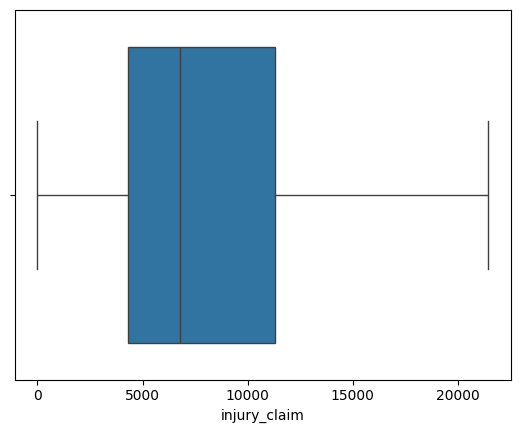

count     1000.00
mean      7399.57
std       4824.73
min          0.00
25%       4445.00
50%       6750.00
75%      10885.00
max      23670.00
Name: property_claim, dtype: float64

626

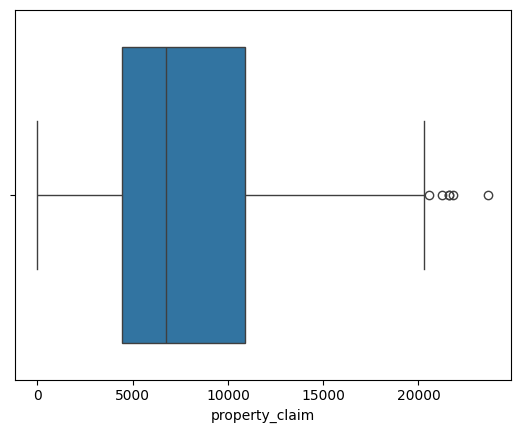

count     1000.00
mean     37928.95
std      18886.25
min         70.00
25%      30292.50
50%      42100.00
75%      50822.50
max      79560.00
Name: vehicle_claim, dtype: float64

726

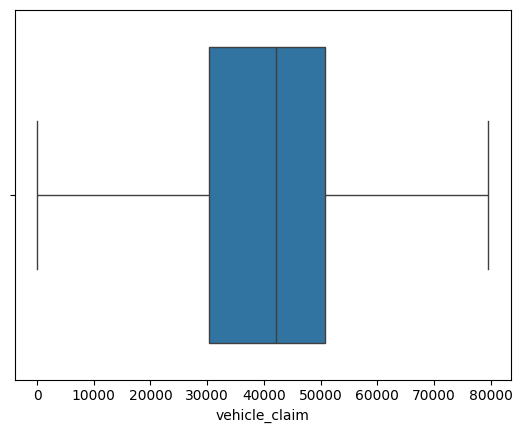

count    1000.00
mean     2005.10
std         6.02
min      1995.00
25%      2000.00
50%      2005.00
75%      2010.00
max      2015.00
Name: auto_year, dtype: float64

21

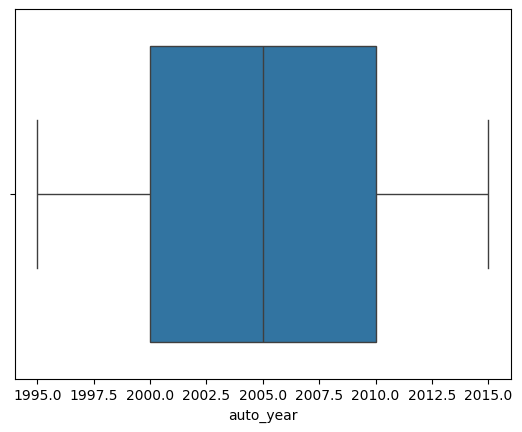

In [33]:
for col in col_quan:
    quant_var_stats(col,df)

In [34]:
df[col_qual].nunique()

policy_bind_date            951
policy_state                  3
policy_csl                    3
insured_sex                   2
insured_education_level       7
insured_occupation           14
insured_hobbies              20
insured_relationship          6
incident_date                60
incident_type                 4
collision_type                4
incident_severity             4
authorities_contacted         4
incident_state                7
incident_city                 7
incident_location          1000
property_damage               3
police_report_available       3
auto_make                    14
auto_model                   39
fraud_reported                2
dtype: int64

Categories repartition: 



incident_type
Multi-vehicle Collision     0.419
Single Vehicle Collision    0.403
Vehicle Theft               0.094
Parked Car                  0.084
Name: proportion, dtype: float64



Contingency table between variable and target variable: 



fraud,0,1
incident_type,,
Multi-vehicle Collision,0.405046,0.461538
Parked Car,0.100930,0.032389
Single Vehicle Collision,0.379814,0.473684
Vehicle Theft,0.114210,0.032389


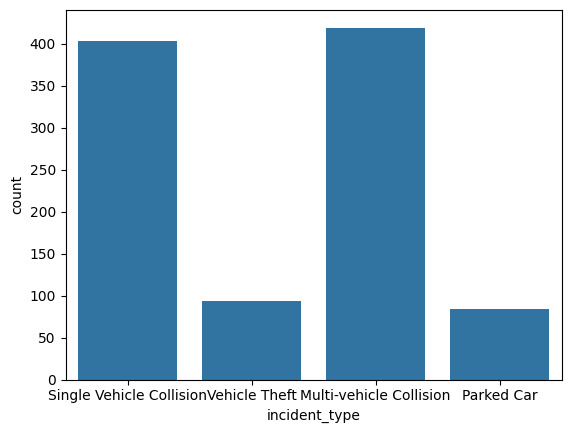

Categories repartition: 



collision_type
Rear Collision     0.292
Side Collision     0.276
Front Collision    0.254
?                  0.178
Name: proportion, dtype: float64



Contingency table between variable and target variable: 



fraud,0,1
collision_type,,
?,0.215139,0.064777
Front Collision,0.244356,0.283401
Rear Collision,0.266932,0.368421
Side Collision,0.273572,0.283401


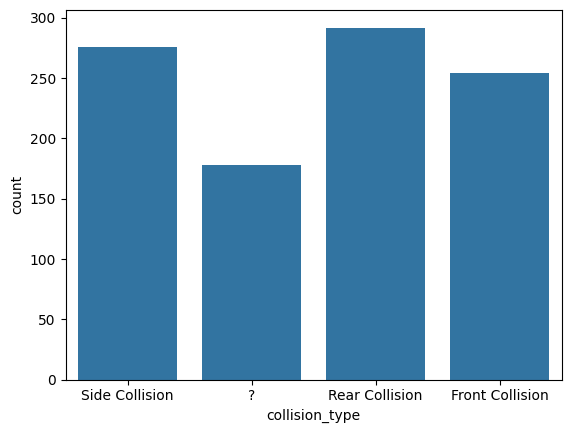

Categories repartition: 



police_report_available
?      0.343
NO     0.343
YES    0.314
Name: proportion, dtype: float64



Contingency table between variable and target variable: 



fraud,0,1
police_report_available,,
?,0.337317,0.360324
NO,0.341301,0.348178
YES,0.321381,0.291498


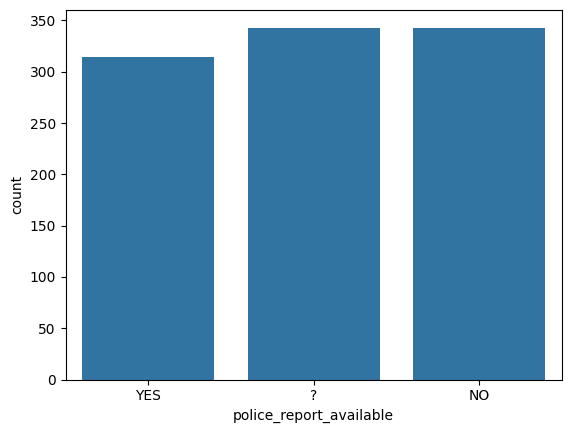

Categories repartition: 



incident_severity
Minor Damage      0.354
Total Loss        0.280
Major Damage      0.276
Trivial Damage    0.090
Name: proportion, dtype: float64



Contingency table between variable and target variable: 



fraud,0,1
incident_severity,,
Major Damage,0.144754,0.676113
Minor Damage,0.419655,0.153846
Total Loss,0.324037,0.145749
Trivial Damage,0.111554,0.024291


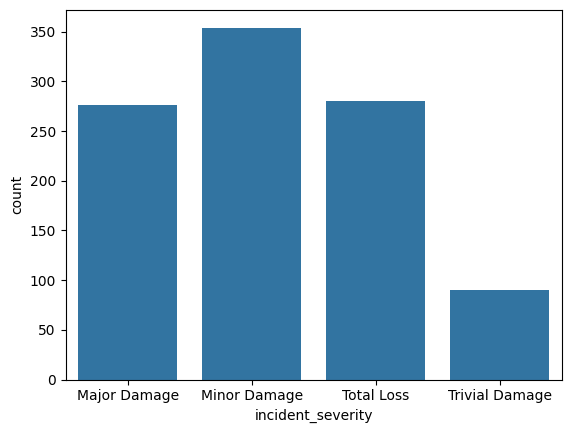

Categories repartition: 



authorities_contacted
Police       0.292
Fire         0.223
Other        0.198
Ambulance    0.196
NaN          0.091
Name: proportion, dtype: float64



Contingency table between variable and target variable: 



fraud,0,1
authorities_contacted,,
Ambulance,0.208084,0.236515
Fire,0.244012,0.248963
Other,0.202096,0.261411
Police,0.345808,0.253112


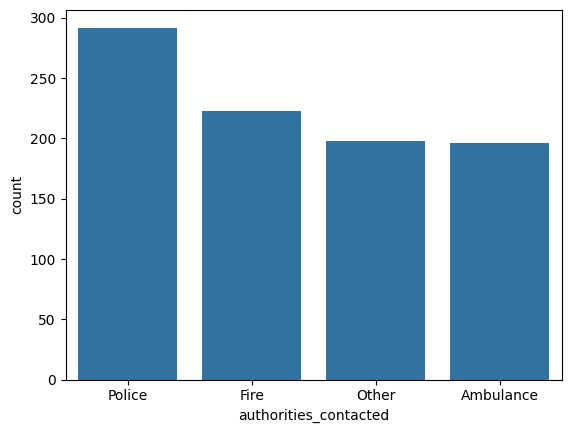

Categories repartition: 



property_damage
?      0.360
NO     0.338
YES    0.302
Name: proportion, dtype: float64



Contingency table between variable and target variable: 



fraud,0,1
property_damage,,
?,0.341301,0.417004
NO,0.361222,0.267206
YES,0.297477,0.315789


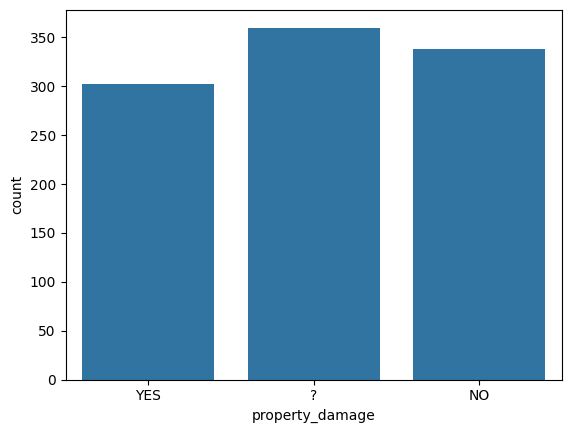

In [44]:
def analyze_binary(variable,target,df):
    print("Categories repartition: ", end="\n\n")
    display(df[variable].value_counts(dropna=False, normalize=True))
    print(end="\n\n")
    print("Contingency table between variable and target variable: ", end="\n\n")
    display(pd.crosstab(df[variable],df[target],normalize=1))
    
    sns.countplot(x=variable, data=df)
    plt.show()
    
analyze_binary('incident_type','fraud',df)
analyze_binary('collision_type','fraud',df)
analyze_binary('police_report_available','fraud',df)
analyze_binary('incident_severity','fraud',df)
analyze_binary('authorities_contacted','fraud',df)
analyze_binary('property_damage','fraud',df)
    

### String Data Cleaning 

In [ ]:
#check string objects
for col in df.drop(expl_col, axis=1).columns:
    if col != "incident_location":
        print(df[col].value_counts())

policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64
insured_occupation
machine-op-inspct    93
prof-specialty       85
tech-support         78
sales                76
exec-managerial      76
craft-repair         74
transport-moving     72
priv-house-serv      71
other-service        71
armed-forces         69
adm-clerical         65
protective-serv      63
handlers-cleaners    54
farming-fishing      53
Name: count, dtype: int64
insured_hobbies
reading           64
exercise          57
paintball         57
bungie-jumping    56
movies            55
camping           55
golf              55
kayaking          54
yachting          53
hiking     

### In these cases are unknown ? values
- property_damage :  ['YES' '?' 'NO']
- police_report_available :  ['YES' '?' 'NO']
- collision_type :  ['Side Collision' '?' 'Rear Collision' 'Front Collision']

In [ ]:
print(df["property_damage"].value_counts())

print(df["police_report_available"].value_counts())

print(df["collision_type"].value_counts())

property_damage
?      360
NO     338
YES    302
Name: count, dtype: int64
police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
?                  178
Name: count, dtype: int64


In [ ]:
# for data viz: check if data of fraud reported is complete
print(df['fraud_reported'].unique())
# for dataviz: is it correlated?
df["fraud"]=df["fraud_reported"].apply(lambda x: 1 if str(x)=="Y" else 0)

['Y' 'N']


In [ ]:
df["fraud"].sum()/1000


np.float64(0.247)

## Data Visualization

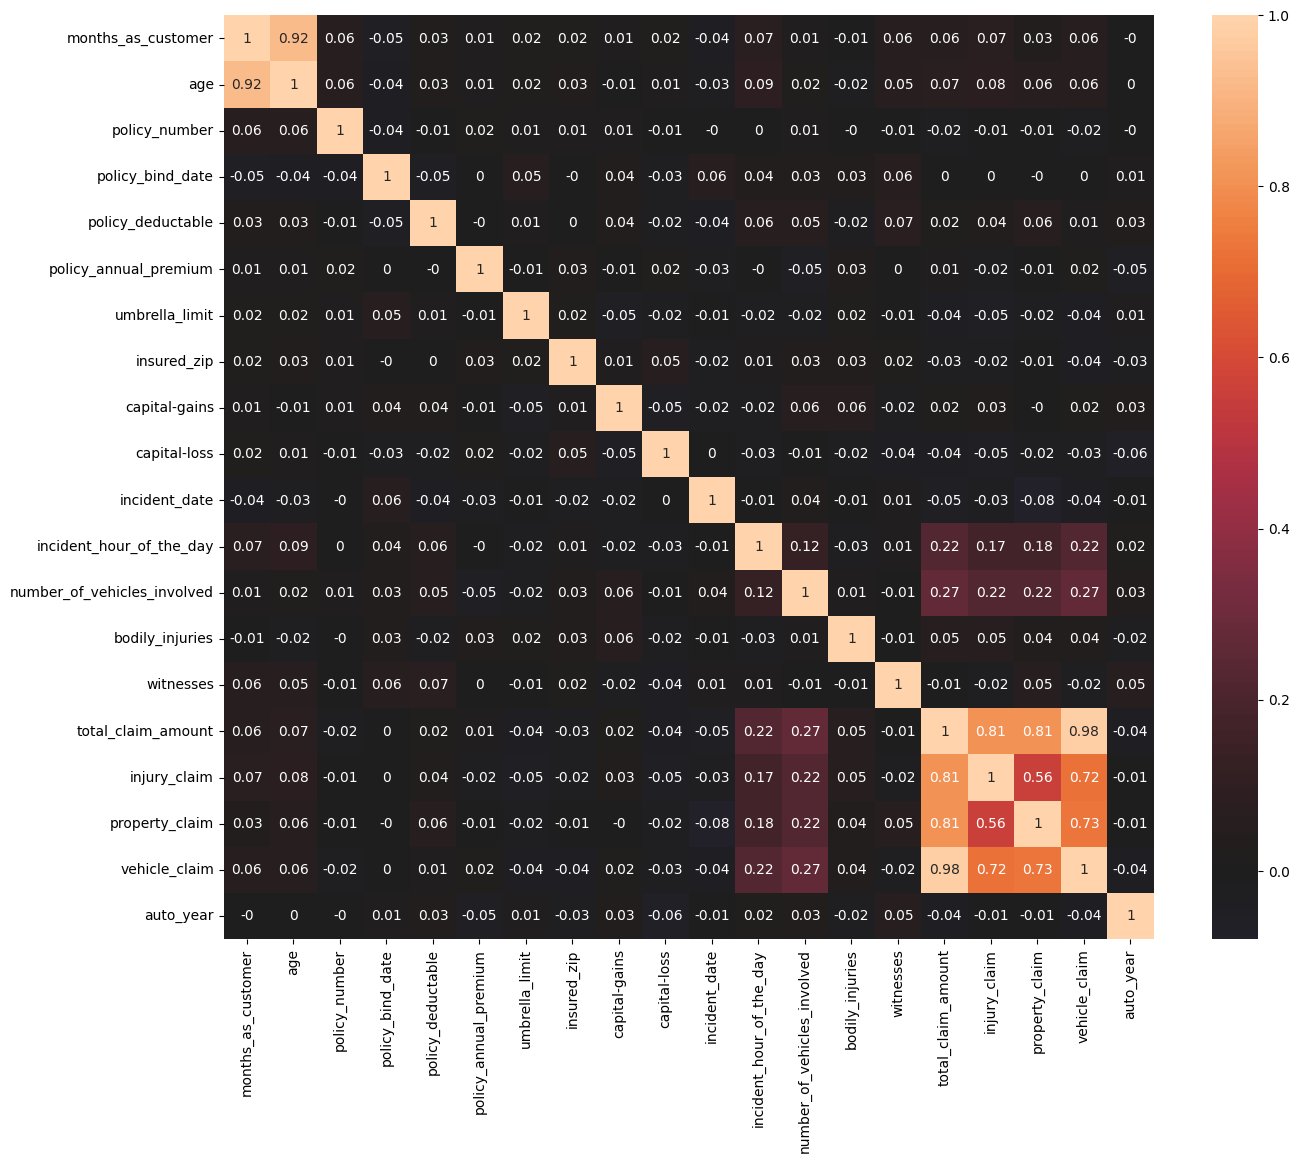

In [ ]:
plt.figure(figsize = (15,12))
sns.heatmap(np.round(df[expl_col].corr(),2), annot=True, center =0);

<Axes: ylabel='Frequency'>

<Figure size 1500x1200 with 0 Axes>

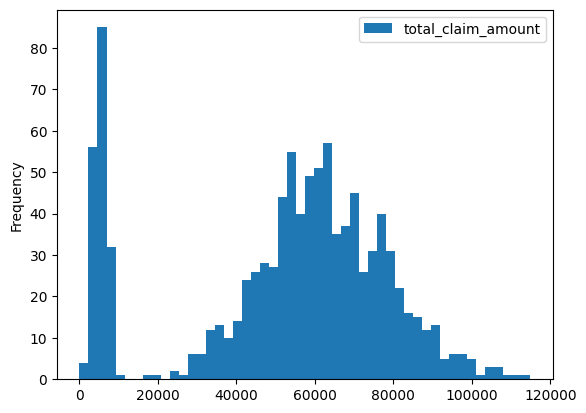

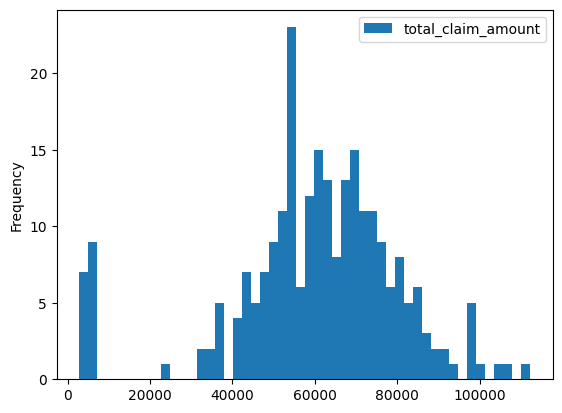

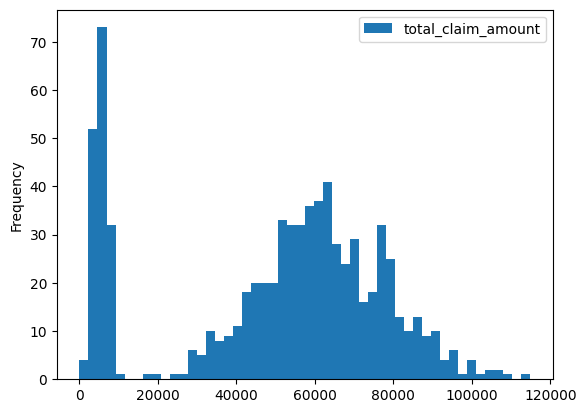

In [ ]:
plt.figure(figsize = (15,12))

df.plot.hist(y="total_claim_amount", bins =50)
df[df["fraud"]==1].plot.hist(y="total_claim_amount", bins =50)
df[df["fraud"]==0].plot.hist(y="total_claim_amount", bins =50)


<Axes: xlabel='police_report_available', ylabel='count'>

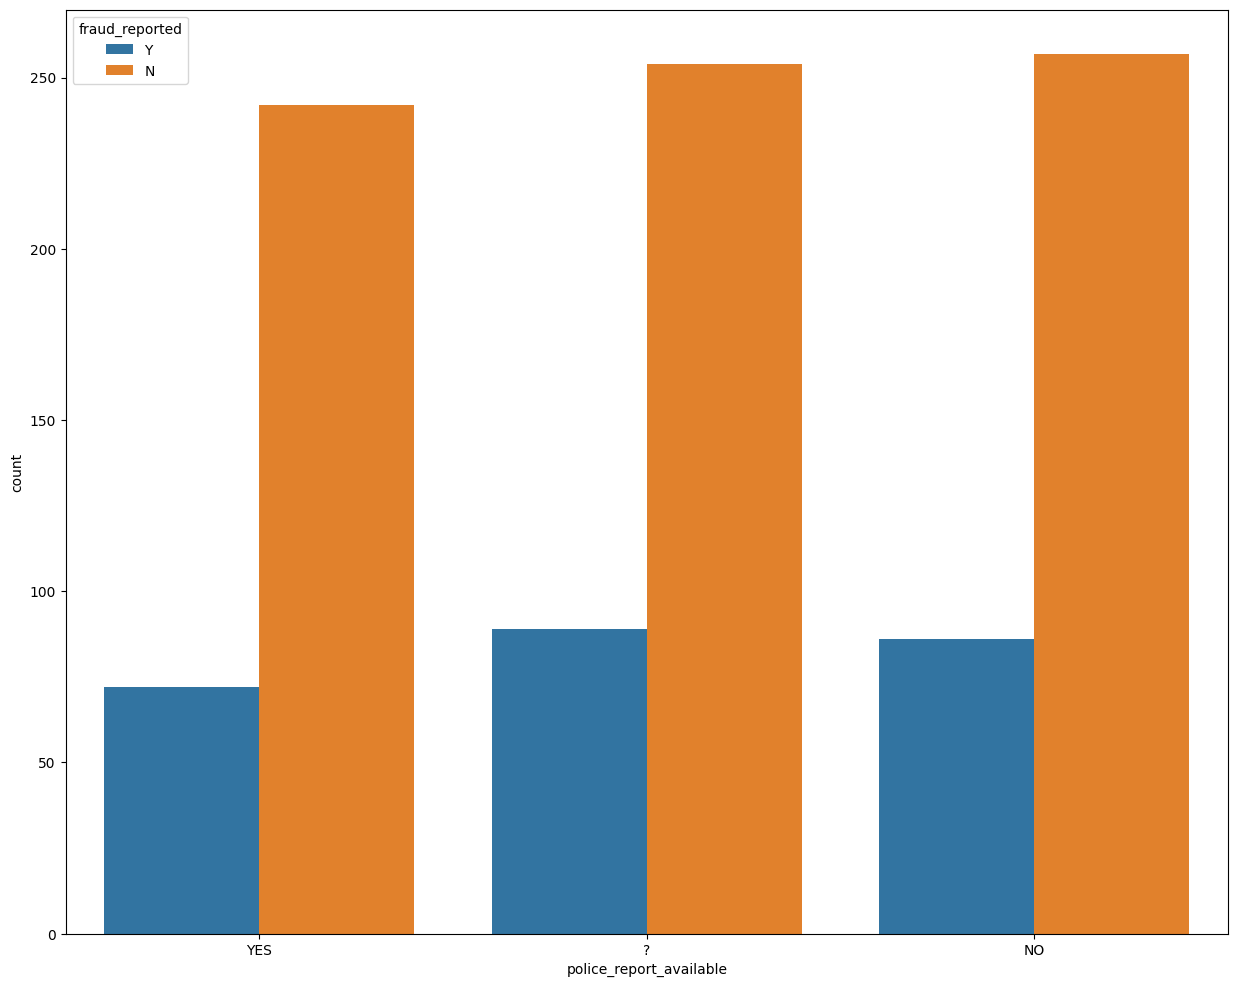

In [ ]:
plt.figure(figsize = (15,12))
sns.countplot(x="police_report_available", data = df, hue="fraud_reported")

<Axes: xlabel='authorities_contacted', ylabel='count'>

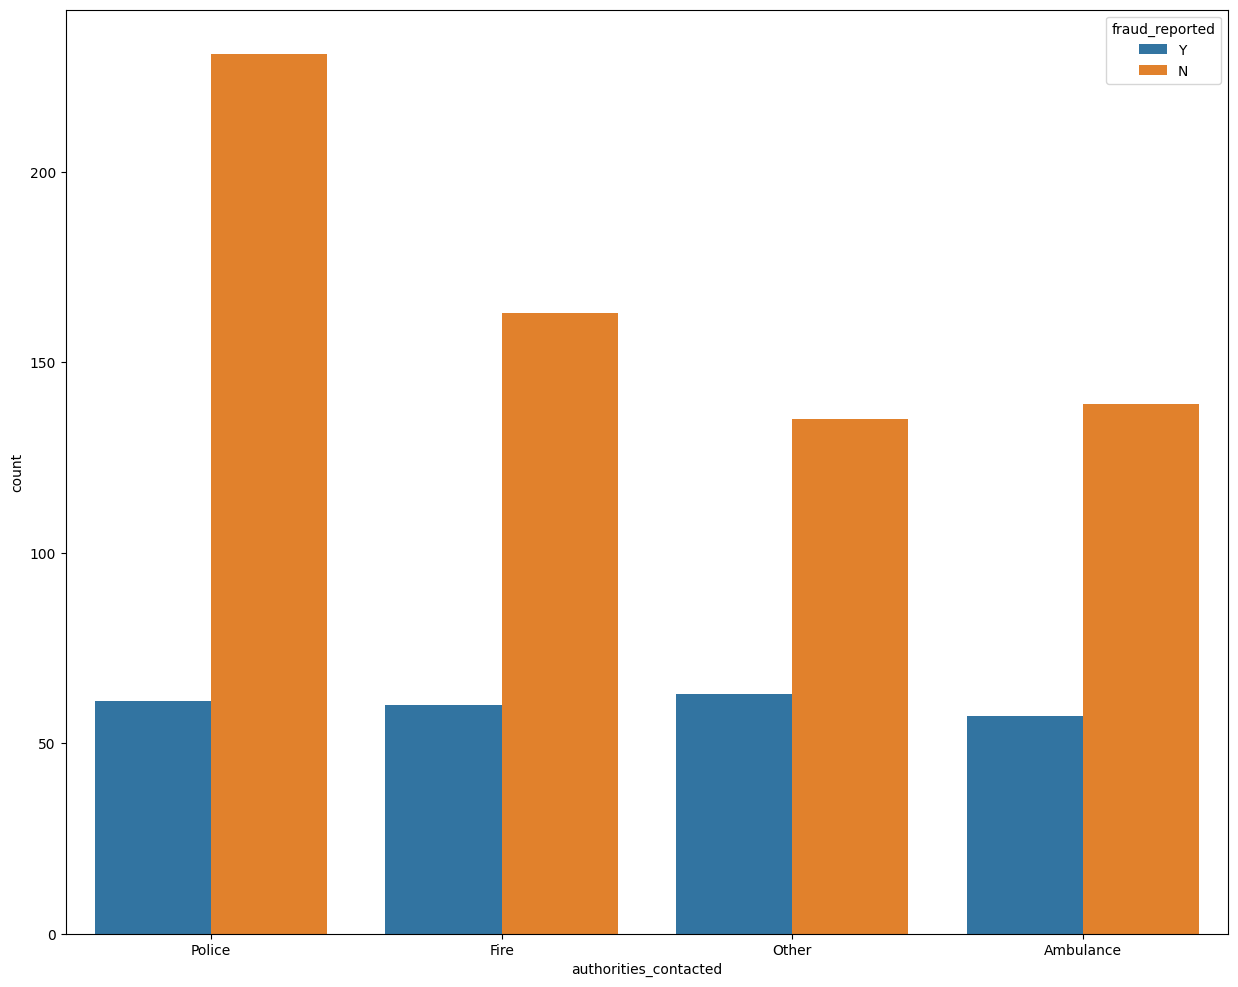

In [ ]:
plt.figure(figsize = (15,12))
sns.countplot(x="authorities_contacted", data = df, hue="fraud_reported")

<Axes: xlabel='incident_hour_of_the_day', ylabel='Count'>

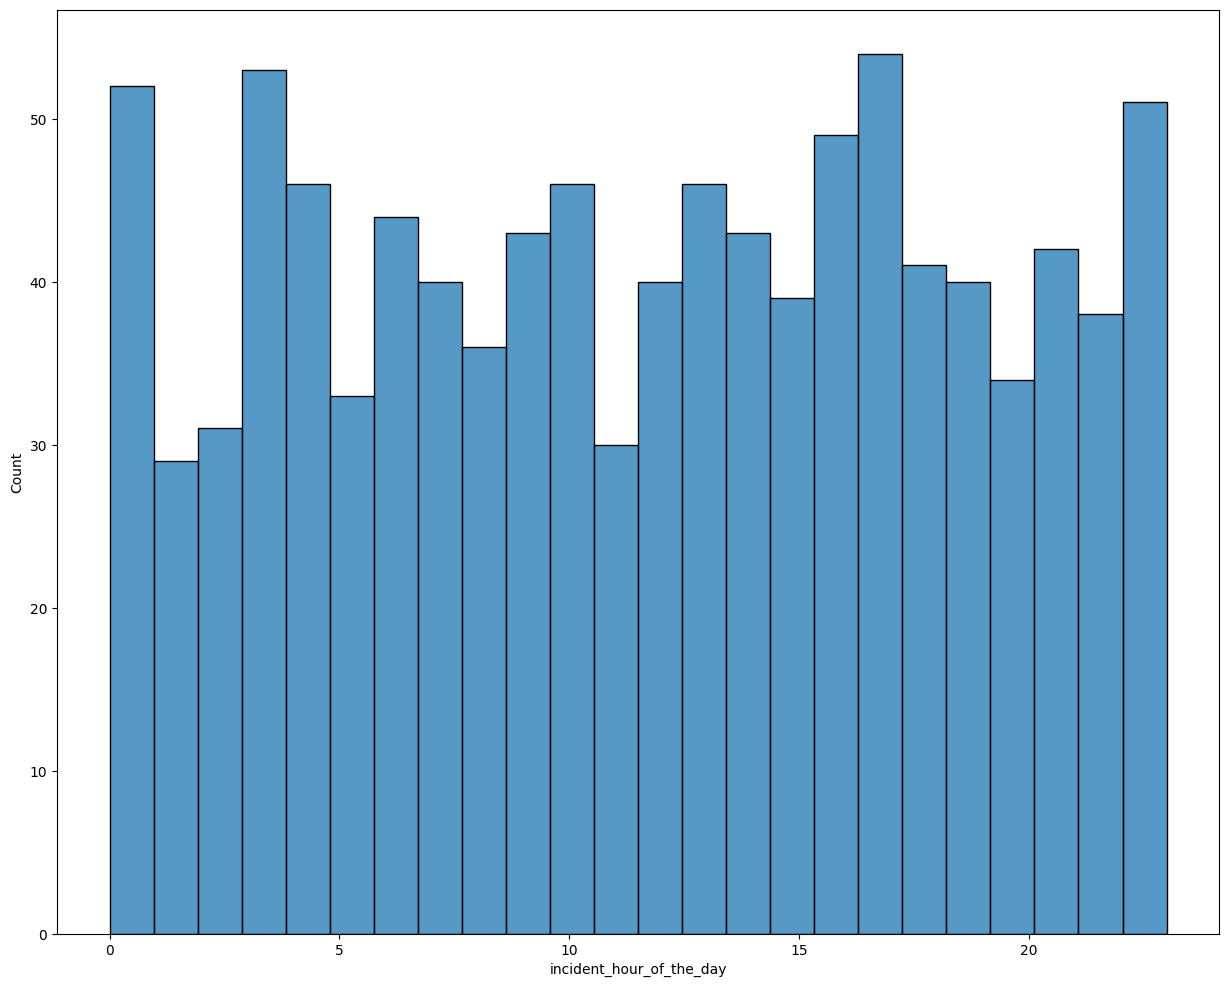

In [ ]:
plt.figure(figsize=(15,12))
sns.histplot(df["incident_hour_of_the_day"], bins =24)